# Introduction: explore climate hazards and climate change hotspots

In this practical session we explore climate hazards and climate change hotspots using real climate datasets.

Climate hazards such as **heatwaves, floods, droughts, and storms** are becoming more frequent and intense due to climate change.

In this exercise you will:
- explore climate datasets from the ERA5 reanalysis
- visualize climate variables linked to extreme events
- identify potential climate hazard hotspots

## What is ERA5?

**ERA5 Climate Reanalysis Dataset**

ERA5 is a global climate reanalysis dataset produced by the **European Centre for Medium-Range Weather Forecasts (ECMWF)** through the **Copernicus Climate Change Service (C3S)**.

A **reanalysis dataset** combines observations from satellites, weather stations, aircraft, and other instruments with numerical weather prediction models to produce a consistent global record of atmospheric conditions.

ERA5 provides hourly estimates of many climate variables including:
- temperature
- precipitation
- wind speed
- soil moisture
- radiation

Key characteristics of ERA5:
- global coverage
- spatial resolution ≈ 31 km
- hourly data from 1940–present
- distributed in NetCDF format

ERA5 is widely used in climate research to study extreme events, climate variability, and long-term trends.

## How to Download ERA5 Data

### Option 1 — Web Interface

ERA5 datasets can be downloaded from the Copernicus Climate Data Store (CDS): https://cds.climate.copernicus.eu/

Steps:

1. Create a free account
2. Go to the Climate Data Store
3. Select a dataset (e.g. ERA5 hourly data)
4. Choose variables, region, and time period
5. Download the dataset in NetCDF format

Example dataset:
> ERA5 monthly averaged data on single levels

Useful variables for hazard analysis:
- 2m temperature → heatwaves
- total precipitation → floods
- soil moisture → drought
- wind speed → storms

### Option 2 — API Download

ERA5 has pretty strict limits on dataset size download limit; sometimes a script is necessary to obtain data covering several years or larger areas. Be warned that sometimes, the download times can be very long. 

First install the CDS client:
> pip install cdsapi

Then configure the API key from the Copernicus account.

The API key must be saved in a configuration file called: 
> .cdsapirc

This file must be placed in your **home directory**.

The file should contain:

    url: https://cds.climate.copernicus.eu/api
    key: <your-user-id>:<your-api-key>

In Google Colab you must create the file manually inside the environment.

    !echo "url: https://cds.climate.copernicus.eu/api
    key: YOUR_UID:YOUR_API_KEY" > ~/.cdsapirc

Example Python request(this script can also be produced in the web UI when you select all download options):

In [1]:
import cdsapi

c = cdsapi.Client()

c.retrieve(
    'reanalysis-era5-single-levels-monthly-means',
    {
        'product_type': 'monthly_averaged_reanalysis',
        'variable': '2m_temperature',
        'year': '2022',
        'month': '07',
        'time': '00:00',
        'format': 'netcdf'
    },
    'era5_temperature.nc')

2026-03-09 09:24:56,379 INFO Request ID is 2446d1ed-69b2-4136-9867-8727324acd4d
2026-03-09 09:24:56,576 INFO status has been updated to accepted
2026-03-09 09:25:05,631 INFO status has been updated to running
2026-03-09 09:25:10,822 INFO status has been updated to successful


5649254a0f1773851e2dc726a1627c62.nc:   0%|          | 0.00/1.33M [00:00<?, ?B/s]

'era5_temperature.nc'

### Load ERA5 Dataset

We use xarray for this

In [2]:
import xarray as xr

ds = xr.open_dataset("era5_temperature.nc")

ds

<xarray.Dataset> Size: 4MB
Dimensions:     (valid_time: 1, latitude: 721, longitude: 1440)
Coordinates:
    number      int64 8B ...
  * valid_time  (valid_time) datetime64[ns] 8B 2022-07-01
  * latitude    (latitude) float64 6kB 90.0 89.75 89.5 ... -89.5 -89.75 -90.0
  * longitude   (longitude) float64 12kB 0.0 0.25 0.5 0.75 ... 359.2 359.5 359.8
    expver      <U4 16B ...
Data variables:
    t2m         (valid_time, latitude, longitude) float32 4MB ...
Attributes:
    GRIB_centre:             ecmf
    GRIB_centreDescription:  European Centre for Medium-Range Weather Forecasts
    GRIB_subCentre:          0
    Conventions:             CF-1.7
    institution:             European Centre for Medium-Range Weather Forecasts
    history:                 2026-03-09T07:25 GRIB to CDM+CF via cfgrib-0.9.1...

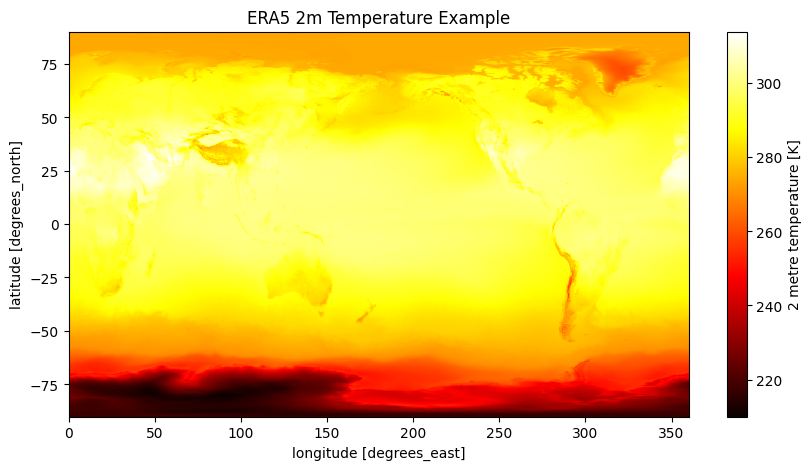

In [6]:
# Example: Plot a Hazard Map
import matplotlib.pyplot as plt

temp = ds['t2m'].isel(valid_time=0)

plt.figure(figsize=(10, 5))
temp.plot(cmap="hot")
plt.title("ERA5 2m Temperature Example")
plt.show()

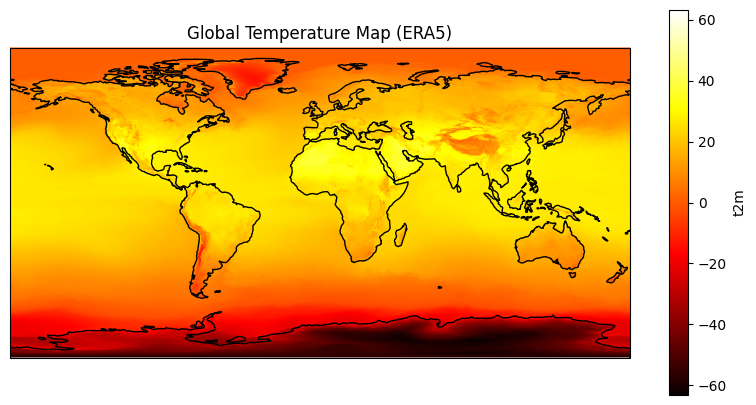

In [9]:
# ERA5 temperature is in Kelvin, convert to C
temp_c = temp - 273.15

# Plot using Cartopy, a library which allows plotting on geographic maps.
import cartopy.crs as ccrs

plt.figure(figsize=(10,5))
ax = plt.axes(projection=ccrs.PlateCarree())

temp_c.plot(ax=ax, transform=ccrs.PlateCarree(), cmap='hot')

ax.coastlines()
plt.title("Global Temperature Map (ERA5)")
plt.show()

## Exercise 1 — Hazard Mapping

Students analyze climate hazard indicators.

**Task** Using ERA5 data:
1. Load a climate variable dataset.
2. Plot a global map.
3. Identify regions with extreme values.

Possible variables:
- temperature → heatwaves
- precipitation → flood risk
- soil moisture → drought risk

**Questions**
- Which regions show the highest temperature anomalies?
- Which areas might be most vulnerable to heatwaves?
- How might these hazards impact local populations?

## Exercise 2 — Climate Hotspot Identification

Students identify climate change hotspots.

**Task** 
1. Choose a region of interest (e.g. Mediterranean).
2. Extract the regional climate data.
3. Analyze trends or extreme values.

**Discussion:** Why might this region be a climate hotspot?

Consider:
- drought
- wildfire risk
- agriculture
- water resources

## Case Study — Mediterranean Hotspot

The Mediterranean region is considered one of the world's most prominent climate change hotspots.

Climate projections indicate increasing:
- heatwaves
- droughts
- wildfire risk

These changes may significantly impact water availability, agriculture, and ecosystems across Southern Europe and North Africa.